In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data_folder = r"C:\Users\palil\Downloads\fma_metadata"

features = pd.read_csv(f"{data_folder}/features.csv", header=[0, 1, 2])
genres = pd.read_csv(f"{data_folder}/genres.csv")
tracks = pd.read_csv(f"{data_folder}/tracks.csv", header=[0, 1], index_col=0)
echonest = pd.read_csv(f"{data_folder}/echonest.csv", header=[0, 1, 2])

C:\Users\palil\AppData\Local\Temp\ipykernel_13212\572399801.py:6: DtypeWarning: Columns (0: ('feature', 'statistics', 'number')) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(f"{data_folder}/features.csv", header=[0, 1, 2])
C:\Users\palil\AppData\Local\Temp\ipykernel_13212\572399801.py:9: DtypeWarning: Columns (0: ('Unnamed: 0_level_0', 'Unnamed: 0_level_1', 'Unnamed: 0_level_2')) have mixed types. Specify dtype option on import or set low_memory=False.
  echonest = pd.read_csv(f"{data_folder}/echonest.csv", header=[0, 1, 2])


In [ ]:
# eliminare las columnas que no son necesarias para el análisis
keep_columns = [("album", "date_released"),
                ("album", "favorites"),
                ("album", "tracks"),
                ("album", "type" ),
                ("album", "listens"),
                ("artist", "favorites"),
                ("track", "bit_rate"),
                ("track", "date_created"),
                ("track", "duration"),
                ("track", "favorites"),
                ("track", "genre_top"),
                ("track", "interest"),
                ("track", "number"),
                ]

tracks = tracks[keep_columns]
print(tracks.info())
tracks

<class 'pandas.DataFrame'>
Index: 106574 entries, 2 to 155320
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   (album, date_released)  70294 non-null   str    
 1   (album, favorites)      106574 non-null  int64  
 2   (album, tracks)         106574 non-null  int64  
 3   (album, type)           100066 non-null  str    
 4   (album, listens)        106574 non-null  int64  
 5   (artist, favorites)     106574 non-null  int64  
 6   (artist, latitude)      44544 non-null   float64
 7   (artist, longitude)     44544 non-null   float64
 8   (track, bit_rate)       106574 non-null  int64  
 9   (track, date_created)   106574 non-null  str    
 10  (track, duration)       106574 non-null  int64  
 11  (track, favorites)      106574 non-null  int64  
 12  (track, genre_top)      49598 non-null   str    
 13  (track, interest)       106574 non-null  int64  
 14  (track, number)         106574 non-n

album                                             \
                date_released favorites tracks              type listens   
track_id                                                                   
2         2009-01-05 00:00:00         4      7             Album    6073   
3         2009-01-05 00:00:00         4      7             Album    6073   
5         2009-01-05 00:00:00         4      7             Album    6073   
10        2008-02-06 00:00:00         4      2             Album   47632   
20        2009-01-06 00:00:00         2     13             Album    2710   
...                       ...       ...    ...               ...     ...   
155316    2017-02-17 00:00:00         0      6  Live Performance    1506   
155317    2017-02-17 00:00:00         0      6  Live Performance    1506   
155318    2017-02-17 00:00:00         0      6  Live Performance    1506   
155319    2017-02-17 00:00:00         0      6  Live Performance    1506   
155320    2017-03-26 00:00:00         1     11             Album    7481   

            artist                          track                       \
         favorites   latitude  longitude bit_rate         date_created   
track_id                                                                 
2                9  40.058324 -74.405661   256000  2008-11-26 01:48:12   
3                9  40.058324 -74.405661   256000  2008-11-26 01:48:14   
5                9  40.058324 -74.405661   256000  2008-11-26 01:48:20   
10              74        NaN        NaN   192000  2008-11-25 17:49:06   
20              10  51.895927   0.891874   256000  2008-11-26 01:48:56   
...            ...        ...        ...      ...                  ...   
155316           0        NaN        NaN   320000  2017-03-30 15:23:34   
155317           0        NaN        NaN   320000  2017-03-30 15:23:36   
155318           0        NaN        NaN   320000  2017-03-30 15:23:37   
155319           0        NaN        NaN   320000  2017-03-30 15:23:39   
155320          12        NaN        NaN   320000  2017-03-30 09:15:36   

                                                       
         duration favorites genre_top interest number  
track_id                                               
2             168         2   Hip-Hop     4656      3  
3             237         1   Hip-Hop     1470      4  
5             206         6   Hip-Hop     1933      6  
10            161       178       Pop    54881      1  
20            311         0       NaN      978      3  
...           ...       ...       ...      ...    ...  
155316        162         1      Rock      122      3  
155317        217         1      Rock      194      4  
155318        404         2      Rock      214      6  
155319        146         0      Rock      336      5  
155320        198         1       NaN      972      7  

[106574 rows x 15 columns]

In [ ]:
# como el objetivo es predecir generos, voy a eliminar todos los nan en la columna genre_top
# esta sera la columna target 
tracks = tracks.dropna(subset=[("track", "genre_top")])

# para todas las columnas de date voy a convertir el formato fecha a int
for col in tracks.columns:
    if "date" in col[1]:
        tracks[col] = pd.to_datetime(tracks[col], errors="coerce").astype("int64")

tracks[("album", "type")].unique()
# voy a hacerlo dummies porque no son tantas categorias
# primero imputo con unknown para no perder los nan
tracks[("album", "type")] = tracks[("album", "type")].fillna("unknown")
tracks = pd.get_dummies(tracks, columns=["album_type"], prefix="album_type", dtype=int)

# ahora si puedo borrar todos los nan
tracks = tracks.dropna()

print(tracks.shape)
print(tracks.info())

(49598, 19)
<class 'pandas.DataFrame'>
Index: 49598 entries, 2 to 155319
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   album_date_released          49598 non-null  int64  
 1   album_favorites              49598 non-null  int64  
 2   album_tracks                 49598 non-null  int64  
 3   album_listens                49598 non-null  int64  
 4   artist_favorites             49598 non-null  int64  
 5   artist_latitude              49598 non-null  float64
 6   artist_longitude             49598 non-null  float64
 7   track_bit_rate               49598 non-null  int64  
 8   track_date_created           49598 non-null  int64  
 9   track_duration               49598 non-null  int64  
 10  track_favorites              49598 non-null  int64  
 11  track_genre_top              49598 non-null  str    
 12  track_interest               49598 non-null  int64  
 13  track_number       

track_genre_top
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

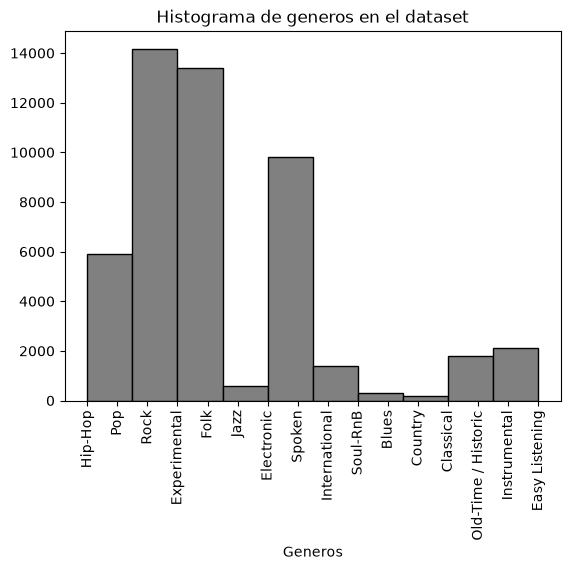

In [26]:
print(tracks["track_genre_top"].value_counts())
# El dataset está muy desbalanceado

plt.hist(tracks["track_genre_top"], color="gray", edgecolor="black")
plt.xticks(rotation=90)
plt.title("Histograma de generos en el dataset")
plt.xlabel("Generos")
plt.show

In [27]:
tracks

,album_date_released,album_favorites,album_tracks,album_listens,artist_favorites,artist_latitude,artist_longitude,track_bit_rate,track_date_created,track_duration,track_favorites,track_genre_top,track_interest,track_number,album_type_Album,album_type_Live Performance,album_type_Radio Program,album_type_Single Tracks,album_type_unknown
track_id,,,,,,,,,,,,,,,,,,,
2,1231113600000000,4,7,6073,9,40.058324,-74.405661,256000,1227664092000000,168,2,Hip-Hop,4656,3,1,0,0,0,0
3,1231113600000000,4,7,6073,9,40.058324,-74.405661,256000,1227664094000000,237,1,Hip-Hop,1470,4,1,0,0,0,0
5,1231113600000000,4,7,6073,9,40.058324,-74.405661,256000,1227664100000000,206,6,Hip-Hop,1933,6,1,0,0,0,0
10,1202256000000000,4,2,47632,74,39.624609,-47.305994,192000,1227635346000000,161,178,Pop,54881,1,1,0,0,0,0
134,1231113600000000,4,7,6073,9,40.058324,-74.405661,256000,1227663799000000,207,3,Hip-Hop,1126,5,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155315,1487289600000000,0,6,1506,0,39.624609,-47.305994,320000,1490887413000000,38,1,Rock,153,1,0,1,0,0,0
155316,1487289600000000,0,6,1506,0,39.624609,-47.305994,320000,1490887414000000,162,1,Rock,122,3,0,1,0,0,0
155317,1487289600000000,0,6,1506,0,39.624609,-47.305994,320000,1490887416000000,217,1,Rock,194,4,0,1,0,0,0
